# Markov State Model construction and analysis from pre-processed time series of a MD simulation of the HP35 protein.

Create new conda venv, install deeptime within it:


```{bash}

conda create -n MSM_env python=3.11
conda activate MSM_env
conda install -c conda-forge deeptime
conda install -c conda-forge matplotlib
conda install -c conda-forge pandas
conda deactivate
```

### Data import


- hp35.dihs: backbone dihedral angles [degrees]
- hp35.dihs.shifted: maximum-gap shifted backbone dihedral angles [rad]
- hp35.crystaldists: the atom distances of all contacts occurring in the crystal structure 2f4k [nm]
- hp35.mindists: all minimal distances occurring more frequently than 30% of the time [nm]
- hp35.mindists2: improved contact distances definition with all atom pairwise distances occurring more frequently than 30% of the time [nm]

In [ ]:
import numpy as np
import deeptime as deep
import matplotlib.pyplot as plt
import pandas as pd


from matplotlib.colors import ListedColormap
binary_cmap = ListedColormap(['white', 'black'])

data_folder = "./data/"

# Time series of the RMSD from the crystal structure

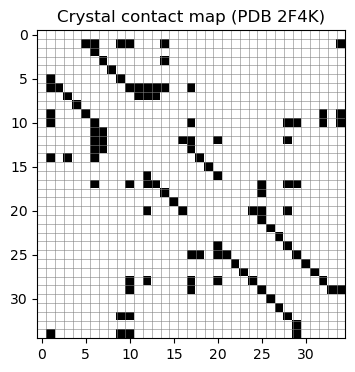

In [13]:
crystal_contacts = [
    tuple(x)
    for x in np.loadtxt(
        data_folder + "hp35.crystaldists.ndx",
        comments="#",
        usecols=(0, 1),
        dtype=int
    )
]

contact_map = np.zeros((35, 35))
for i in range(35):
    for j in range(35):
        if (i,j) in crystal_contacts:
            contact_map[i, j] = 1
            contact_map[j, i] = 1


fig, ax = plt.subplots(figsize = (5,4))
n = contact_map.shape[0]
ax.imshow(contact_map, cmap = binary_cmap)
# 1x1 cell grid
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.4)
ax.tick_params(which="minor", bottom=False, left=False)
# title
ax.set_title("Crystal contact map (PDB 2F4K)")
ax.set_aspect("equal")

In [14]:
crystal_dis_array = np.loadtxt(data_folder + "hp35.crystaldists", delimiter = " ", dtype = float)

crystal_dis_array.shape # [nm] nanometers

(1526041, 53)

In [15]:
nframes = crystal_dis_array.shape[0]
simulation_length = 305 #microseconds
time_between_frames = simulation_length / nframes


print("Time between frames: (fs)", time_between_frames * 10**9)
# Is this the timestep of the original simulation? No, it cannot be. It is too large. Usually, the simulation step in all-atom simulation is around $~2 fs$. 
# Most likely, they saved the frames every X integration timesteps.
print("Probable frame storage rate:", 1/ (time_between_frames * 10**9 / 2))

Time between frames: (fs) 199863.56854108113
Probable frame storage rate: 1.0006826229508197e-05


In [ ]:
RMSD_timeseries =np.sqrt(np.mean(crystal_dis_array**2, axis = 1)) * 10 # Armstrong

np.save("intermediate_outputs/RMSD_crystal_nm", RMSD_timeseries / 10)


time = np.arange(0, nframes) * time_between_frames
w = 10**4 # window size
MA_RMSD_timeseries = np.convolve(RMSD_timeseries, np.ones(w)/w, mode='same')

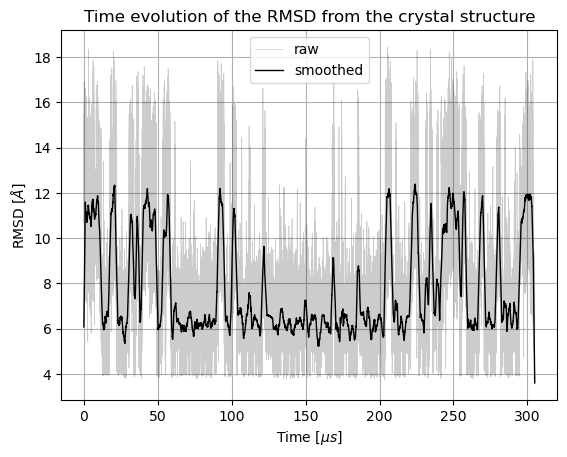

In [17]:
fig, ax = plt.subplots()
ax.plot(time, RMSD_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, MA_RMSD_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"RMSD [$Å$]")
ax.legend()
ax.grid()
ax.set_title("Time evolution of the RMSD from the crystal structure")
plt.show()

## Native contacts, inferred from the *simulation*

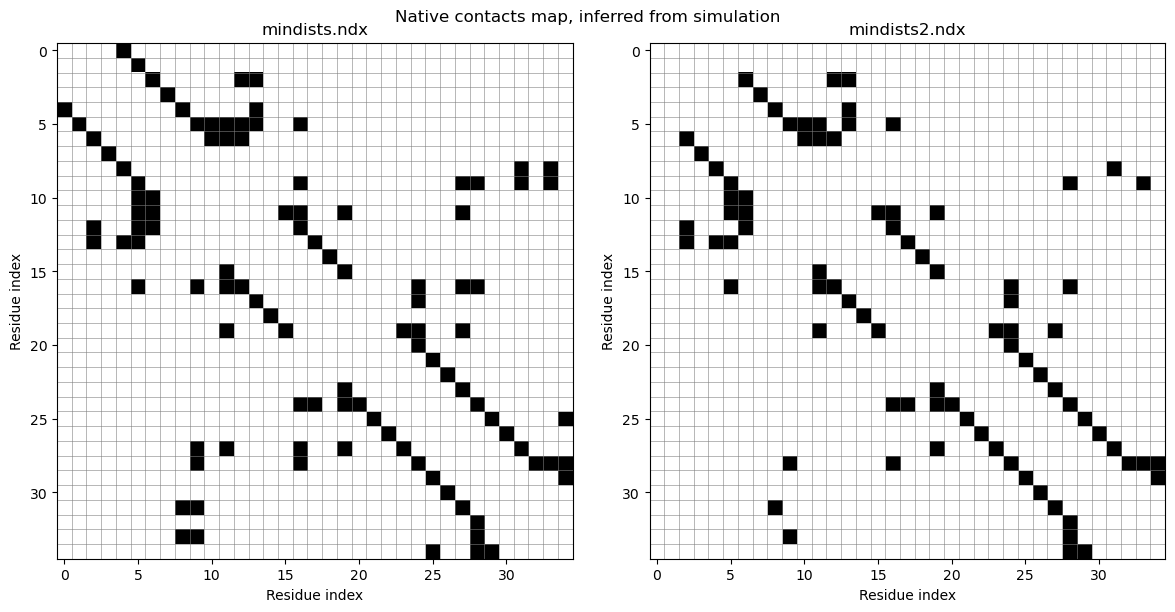

In [18]:

# ---------- LEFT PANEL : mindists.ndx ----------

native_contacts_left = [
    tuple(x)
    for x in np.loadtxt(
        data_folder + "hp35.mindists.ndx",
        comments="#",
        usecols=(0, 1),
        dtype=int
    )
]

contact_map_left = np.zeros((35, 35))

for i, j in native_contacts_left:
    contact_map_left[i-1, j-1] = 1
    contact_map_left[j-1, i-1] = 1


# ---------- RIGHT PANEL : current file ----------

native_contacts_right = [
    tuple(x)
    for x in np.loadtxt(
        data_folder + "hp35.mindists2.ndx",
        comments="#",
        usecols=(0, 1),
        dtype=int
    )
]

contact_map_right = np.zeros((35, 35))

for i, j in native_contacts_right:
    contact_map_right[i-1, j-1] = 1
    contact_map_right[j-1, i-1] = 1


# ---------- PLOT ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

maps = [
    (contact_map_left, "mindists.ndx"),
    (contact_map_right, "mindists2.ndx")
]

for ax, (contact_map, title) in zip(axes, maps):

    n = contact_map.shape[0]

    ax.imshow(
        contact_map,
        cmap=binary_cmap,
        #origin="lower",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    # 1x1 grid
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)

    ax.grid(
        which="minor",
        color="gray",
        linestyle="-",
        linewidth=0.4
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_title(title)

    ax.set_xlabel("Residue index")
    ax.set_ylabel("Residue index")

    ax.set_aspect("equal")

plt.suptitle("Native contacts map, inferred from simulation")
plt.tight_layout()
plt.show()

In [19]:
mindists2_array = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float) * 10 # armstrong

mindists2_array.shape # [nm] nanometers

(1526041, 42)

In [20]:
# two residues are considered in contact if the min. distance between non-hydrogen atoms is less than 4.5 Å = 0.45 nm.
# Q is defined as the fraction of native contacts
binary_contact_timeseries = np.where(mindists2_array < 4.5, 1, 0) 
Q_timeseries = np.sum(binary_contact_timeseries, axis = 1) / mindists2_array.shape[1]
MA_Q_timeseries = np.convolve(Q_timeseries, np.ones(w)/w, mode='same')

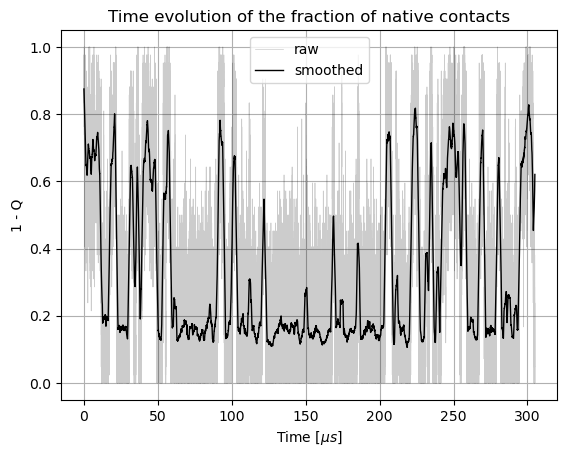

In [21]:
fig, ax = plt.subplots()
ax.plot(time, 1 - Q_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, 1 - MA_Q_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"1 - Q")
ax.legend()
ax.grid()
ax.set_title("Time evolution of the fraction of native contacts")
plt.show()

## Dihedrals 

Phi: $\Phi$
Psi: $\Psi$

In [41]:
dihedral_names = np.loadtxt(data_folder + "hp35.dihs.names", comments = ["#", "\n"], dtype = str)

33.0


/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_24030/2214181344.py:1: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  dihedral_names = np.loadtxt(data_folder + "hp35.dihs.names", comments = ["#", "\n"], dtype = str)


In [43]:
print(len(dihedral_names)/2)

33.0


In [42]:
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float)
phis_timeseries = dihedral_timeseries[:, 0::2] # degrees
psis_timeseries = dihedral_timeseries[:, 1::2] # degrees
print(dihedral_timeseries.shape)

(1526041, 66)


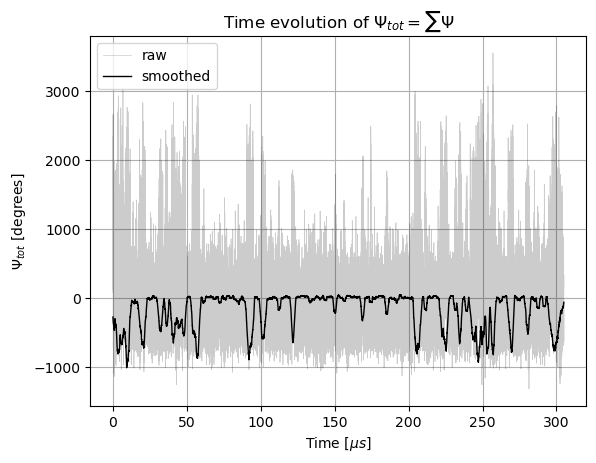

In [34]:
total_psi_timeseries = np.sum(psis_timeseries, axis = 1)
MA_total_psi_timeseries = np.convolve(total_psi_timeseries, np.ones(w)/w, mode='same')

fig, ax = plt.subplots()
ax.plot(time, total_psi_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, 1 - MA_total_psi_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"$\Psi_{tot}$ [degrees]")
ax.legend()
ax.grid()
ax.set_title(r"Time evolution of $\Psi_{tot} = \sum \Psi$")
plt.show()

In [38]:
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
dihedral_timeseries.shape

(1526041, 66)